# 🛒 E-commerce Sales Analysis with PySpark

**Dataset:** UCI Online Retail Dataset | 541,909 transactions | Dec 2010 – Dec 2011  
**Stack:** PySpark 4.1 | Java 17 | Jupyter Notebook | Matplotlib | Seaborn

---

## 📌 Project Overview

End-to-end Big Data pipeline built on 500k+ real e-commerce transactions from a UK-based online retailer. The goal is to extract actionable business insights using distributed data processing and customer segmentation.

---

## Phase 1 — Data Loading & Exploration

### 1.1 Environment Setup
- Configured PySpark 4.1 with Java 17 (Eclipse Temurin)
- Initialised SparkSession with eager evaluation enabled for notebook rendering

### 1.2 Dataset Overview

| Column | Type | Description |
|---|---|---|
| InvoiceNo | String | Unique transaction ID (prefix 'C' = cancellation) |
| StockCode | String | Product code |
| Description | String | Product name |
| Quantity | Integer | Units purchased |
| InvoiceDate | Timestamp | Date and time of transaction |
| UnitPrice | Double | Price per unit (£) |
| CustomerID | Double | Unique customer identifier |
| Country | String | Customer country |

### 1.3 Initial Statistics

| Metric | Value |
|---|---|
| Total rows | 541,909 |
| Total columns | 8 |
| Unique countries | 38 |
| Null CustomerIDs | 135,080 |
| Null Descriptions | 1,454 |

### 1.4 Top 10 Countries by Orders

| Country | Orders |
|---|---|
| United Kingdom | 495,478 |
| Germany | 9,495 |
| France | 8,557 |
| EIRE | 8,196 |
| Spain | 2,533 |

> 🔍 **Insight:** United Kingdom accounts for ~91% of all transactions, indicating a heavily UK-centric customer base.

---

## Phase 2 — Data Cleaning & Feature Engineering

### 2.1 Cleaning Steps

| Step | Action | Rows Removed |
|---|---|---|
| Remove null CustomerIDs | dropna(subset=["CustomerID"]) | 135,080 |
| Remove cancellations | filter InvoiceNo not starting with 'C' | ~8,872 |
| Remove bad quantities/prices | filter Quantity > 0 and UnitPrice > 0 | ~73 |
| **Final clean rows** | | **397,884** |

### 2.2 Feature Engineering

New columns added:
- **TotalRevenue** = Quantity × UnitPrice (rounded to 2 decimal places)
- **Month** = extracted from InvoiceDate
- **Year** = extracted from InvoiceDate

---

## Phase 2 — Analysis & Insights

### 2.3 Monthly Revenue Trend

| Month | Revenue (£) | Orders | Unique Customers |
|---|---|---|---|
| 2010-12 | 572,713.89 | 1,400 | 885 |
| 2011-02 | 447,137.35 | 997 | 758 | ← lowest month |
| 2011-09 | 952,838.38 | 1,755 | 1,266 |
| 2011-10 | 1,039,318.79 | 1,929 | 1,364 |
| **2011-11** | **1,161,817.38** | **2,657** | **1,664** | ← **peak month** |

> 🔍 **Insight:** Revenue surged **+47.6% in September 2011** (MoM), driven by holiday season demand. November 2011 peaked at **£1.16M** — the highest month on record.

### 2.4 RFM Customer Segmentation

RFM (Recency, Frequency, Monetary) segments customers based on purchasing behaviour. Each customer is scored 1–4 on each dimension, giving a combined RFM Score of 3–12.

| Segment | RFM Score | Description |
|---|---|---|
| Champions | 10–12 | Bought recently, buy often, spend the most |
| Loyal Customers | 8–9 | Regular buyers with high spend |
| Potential Loyalists | 6–7 | Recent buyers with moderate frequency |
| At Risk | 4–5 | Used to buy but haven't recently |
| Lost | 3 | Haven't bought in a long time, low spend |

### 2.5 Segment Summary

| Segment | Customers | Avg Recency (days) | Avg Frequency | Avg Monetary (£) |
|---|---|---|---|---|
| **Champions** | **~1,300** | low | high | **highest** |
| Loyal Customers | ~800 | moderate | moderate | moderate |
| Potential Loyalists | ~950 | low-moderate | low | low-moderate |
| At Risk | ~800 | high | low | low |
| Lost | ~430 | very high | very low | very low |

> 🔍 **Key Insight:** ~1,300 Champion customers generated nearly **£7M in revenue** — the vast majority of total business value. Retaining Champions is the single highest-leverage business action.

> 🔍 **Notable finding:** Customer 16446 spent £168,472 in just 2 orders — a high-value bulk buyer. Customer 14911 made 201 separate orders — the most loyal repeat customer in the dataset.

---

## Visualisations

Three charts produced:
1. **Monthly Revenue Trend** — line chart showing Dec 2010 – Dec 2011 trajectory
2. **RFM Segment Distribution** — dual bar chart (customers vs revenue per segment)
3. **Recency vs Monetary Scatter** — colour-coded by RFM score showing customer clustering

## Phase 3 — Spark SQL Analysis

Registered cleaned DataFrame and RFM segments as Spark SQL temp views, then ran analytical queries covering the full range of SQL concepts tested in DS/DE interviews.

---

### 3.1 Top 10 Countries by Revenue (excl. UK)

```sql
SELECT Country, COUNT(DISTINCT InvoiceNo) AS Orders,
       COUNT(DISTINCT CustomerID) AS Customers,
       ROUND(SUM(TotalRevenue), 2) AS Revenue
FROM retail
WHERE Country != 'United Kingdom'
GROUP BY Country ORDER BY Revenue DESC
```

| Country | Orders | Customers | Revenue (£) |
|---|---|---|---|
| Netherlands | 94 | 9 | 285,446.34 |
| EIRE | 260 | 3 | 265,545.90 |
| Germany | 457 | 94 | 228,867.14 |
| France | 389 | 87 | 209,024.05 |
| Australia | 57 | 9 | 138,521.31 |

> 🔍 **Insight:** Netherlands has only 9 customers but generates £285k — the highest revenue-per-customer ratio of any country outside the UK.

---

### 3.2 High-Value Customers (Spend > £5,000)

```sql
SELECT CustomerID, COUNT(DISTINCT InvoiceNo) AS Orders,
       ROUND(SUM(TotalRevenue), 2) AS TotalSpent
FROM retail
GROUP BY CustomerID
HAVING TotalSpent > 5000
ORDER BY TotalSpent DESC
```

| CustomerID | Orders | Total Spent (£) |
|---|---|---|
| 14646 | 73 | 280,206.02 |
| 18102 | 60 | 259,657.30 |
| 17450 | 46 | 194,550.79 |
| 16446 | 2 | 168,472.50 |
| 14911 | 201 | 143,825.06 |

> 🔍 **Concept used:** `HAVING` — filters after aggregation, unlike `WHERE` which filters before.

---

### 3.3 Top Customer per Country (Window Function — RANK)

```sql
SELECT Country, CustomerID, Revenue, CountryRank
FROM (
    SELECT Country, CustomerID,
           ROUND(SUM(TotalRevenue), 2) AS Revenue,
           RANK() OVER (PARTITION BY Country ORDER BY SUM(TotalRevenue) DESC) AS CountryRank
    FROM retail
    GROUP BY Country, CustomerID
)
WHERE CountryRank = 1
ORDER BY Revenue DESC
```

| Country | CustomerID | Revenue (£) | Rank |
|---|---|---|---|
| Netherlands | 14646 | 280,206.02 | 1 |
| United Kingdom | 18102 | 259,657.30 | 1 |
| EIRE | 14911 | 143,825.06 | 1 |
| Australia | 12415 | 124,914.53 | 1 |

> 🔍 **Concept used:** `RANK() OVER (PARTITION BY ...)` — ranks rows within each group independently. Window function aliases must be referenced in an outer subquery, not in the same WHERE clause.

---

### 3.4 Month-over-Month Revenue Growth (Window Function — LAG)

```sql
SELECT Year, Month, Revenue,
       LAG(Revenue) OVER (ORDER BY Year, Month) AS PrevMonthRevenue,
       ROUND((Revenue - LAG(Revenue) OVER (ORDER BY Year, Month))
             / LAG(Revenue) OVER (ORDER BY Year, Month) * 100, 1) AS GrowthPct
FROM (
    SELECT Year, Month, ROUND(SUM(TotalRevenue), 2) AS Revenue
    FROM retail GROUP BY Year, Month
)
ORDER BY Year, Month
```

| Month | Revenue (£) | Prev Month (£) | Growth % |
|---|---|---|---|
| 2011-02 | 447,137 | 569,445 | -21.5% |
| 2011-05 | 678,594 | 469,200 | +44.6% |
| **2011-09** | **952,838** | **645,343** | **+47.6%** ← biggest jump |
| 2011-11 | 1,161,817 | 1,039,318 | +11.8% |
| 2011-12 | 518,192 | 1,161,817 | -55.4% ← dataset cutoff |

> 🔍 **Insight:** September 2011 recorded the largest single month-over-month jump at +47.6%, marking the start of the holiday season surge.  
> 🔍 **Concept used:** `LAG()` — accesses the value from the previous row in the result set, essential for time-series comparisons.

---

### 3.5 Champion Customers with Country (JOIN)

```sql
SELECT r.CustomerID, t.Country, r.Segment,
       r.Recency, r.Frequency, r.Monetary
FROM rfm r
JOIN (SELECT DISTINCT CustomerID, Country FROM retail) t
  ON r.CustomerID = t.CustomerID
WHERE r.Segment = 'Champions'
ORDER BY r.Monetary DESC
```

| CustomerID | Country | Recency | Frequency | Monetary (£) |
|---|---|---|---|---|
| 14646 | Netherlands | 1 day | 73 orders | 280,206.02 |
| 18102 | United Kingdom | 0 days | 60 orders | 259,657.30 |
| 16446 | United Kingdom | 0 days | 2 orders | 168,472.50 |
| 14911 | EIRE | 1 day | 201 orders | 143,825.06 |

> 🔍 **Concept used:** `JOIN` across two temp views — combining RFM segment data with transactional data to enrich customer profiles.

---

### 3.6 SQL Concepts Covered

| Concept | Used in |
|---|---|
| GROUP BY + ORDER BY | Country revenue ranking |
| HAVING | High-value customer filter |
| Subquery | Above-average spend filter |
| RANK() OVER PARTITION BY | Top customer per country |
| SUM() OVER | Running total per customer |
| LAG() | Month-over-month growth |
| JOIN | Champions enriched with country |

In [1]:
import os
os.environ["JAVA_HOME"] = r"C:\Program Files\Eclipse Adoptium\jdk-17.0.19.10-hotspot"
os.environ["PATH"] = os.environ["JAVA_HOME"] + r"\bin;" + os.environ["PATH"]
os.environ.pop("JAVA_TOOL_OPTIONS", None)
os.environ["HADOOP_HOME"] = r"C:\hadoop"
os.environ["PATH"] = r"C:\hadoop\bin;" + os.environ["PATH"]

In [2]:
!java -version

openjdk version "17.0.19" 2026-04-21
OpenJDK Runtime Environment Temurin-17.0.19+10 (build 17.0.19+10)
OpenJDK 64-Bit Server VM Temurin-17.0.19+10 (build 17.0.19+10, mixed mode, sharing)


In [3]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = SparkSession.builder \
    .appName("EcommerceAnalysis") \
    .config("spark.sql.repl.eagerEval.enabled", True) \
    .getOrCreate()

print(spark.version)

4.1.2


In [4]:
df = (spark.read
    .option("header", True)
    .option("inferSchema", True)
    .option("encoding", "ISO-8859-1")
    .csv("data/online_retail.csv")
)

df.printSchema()
print(f"Total rows: {df.count()}")

root
 |-- InvoiceNo: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: timestamp (nullable = true)
 |-- UnitPrice: double (nullable = true)
 |-- CustomerID: integer (nullable = true)
 |-- Country: string (nullable = true)

Total rows: 541909


In [5]:
null_counts = df.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in df.columns
])
null_counts.show()

+---------+---------+-----------+--------+-----------+---------+----------+-------+
|InvoiceNo|StockCode|Description|Quantity|InvoiceDate|UnitPrice|CustomerID|Country|
+---------+---------+-----------+--------+-----------+---------+----------+-------+
|        0|        0|       1454|       0|          0|        0|    135080|      0|
+---------+---------+-----------+--------+-----------+---------+----------+-------+



In [6]:
df.groupBy("Country") \
  .count() \
  .orderBy(F.desc("count")) \
  .show(10)

+--------------+------+
|       Country| count|
+--------------+------+
|United Kingdom|495478|
|       Germany|  9495|
|        France|  8557|
|          EIRE|  8196|
|         Spain|  2533|
|   Netherlands|  2371|
|       Belgium|  2069|
|   Switzerland|  2002|
|      Portugal|  1519|
|     Australia|  1259|
+--------------+------+
only showing top 10 rows


In [7]:
df_clean = df.dropna(subset=["CustomerID"])
df_clean = df_clean.filter(~F.col("InvoiceNo").startswith("C"))
df_clean = df_clean.filter(
    (F.col("Quantity") > 0) & (F.col("UnitPrice") > 0)
)

print(f"Rows after cleaning: {df_clean.count()}")

Rows after cleaning: 397884


In [8]:
df_clean = (df_clean
    .withColumn("InvoiceDate", F.to_timestamp("InvoiceDate", "M/d/yyyy H:mm"))
    .withColumn("TotalRevenue", F.col("Quantity") * F.col("UnitPrice"))
    .withColumn("Month", F.month("InvoiceDate"))
    .withColumn("Year", F.year("InvoiceDate"))
)

df_clean.show(3)

+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+------------------+-----+----+
|InvoiceNo|StockCode|         Description|Quantity|        InvoiceDate|UnitPrice|CustomerID|       Country|      TotalRevenue|Month|Year|
+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+------------------+-----+----+
|   536365|   85123A|WHITE HANGING HEA...|       6|2010-12-01 08:26:00|     2.55|     17850|United Kingdom|15.299999999999999|   12|2010|
|   536365|    71053| WHITE METAL LANTERN|       6|2010-12-01 08:26:00|     3.39|     17850|United Kingdom|             20.34|   12|2010|
|   536365|   84406B|CREAM CUPID HEART...|       8|2010-12-01 08:26:00|     2.75|     17850|United Kingdom|              22.0|   12|2010|
+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+------------------+-----+----+
only showing top 3 rows


In [9]:
df_clean = df_clean.withColumn("TotalRevenue", F.round(F.col("TotalRevenue"), 2))
df_clean.show(3)

+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+------------+-----+----+
|InvoiceNo|StockCode|         Description|Quantity|        InvoiceDate|UnitPrice|CustomerID|       Country|TotalRevenue|Month|Year|
+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+------------+-----+----+
|   536365|   85123A|WHITE HANGING HEA...|       6|2010-12-01 08:26:00|     2.55|     17850|United Kingdom|        15.3|   12|2010|
|   536365|    71053| WHITE METAL LANTERN|       6|2010-12-01 08:26:00|     3.39|     17850|United Kingdom|       20.34|   12|2010|
|   536365|   84406B|CREAM CUPID HEART...|       8|2010-12-01 08:26:00|     2.75|     17850|United Kingdom|        22.0|   12|2010|
+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+------------+-----+----+
only showing top 3 rows


In [10]:
monthly_revenue = (df_clean
    .groupBy("Year", "Month")
    .agg(
        F.round(F.sum("TotalRevenue"), 2).alias("Revenue"),
        F.countDistinct("InvoiceNo").alias("Orders"),
        F.countDistinct("CustomerID").alias("UniqueCustomers")
    )
    .orderBy("Year", "Month")
)
monthly_revenue.show()

+----+-----+----------+------+---------------+
|Year|Month|   Revenue|Orders|UniqueCustomers|
+----+-----+----------+------+---------------+
|2010|   12| 572713.89|  1400|            885|
|2011|    1| 569445.04|   987|            741|
|2011|    2| 447137.35|   997|            758|
|2011|    3| 595500.76|  1321|            974|
|2011|    4| 469200.36|  1149|            856|
|2011|    5| 678594.56|  1555|           1056|
|2011|    6| 661213.69|  1393|            991|
|2011|    7| 600091.01|  1331|            949|
|2011|    8|  645343.9|  1280|            935|
|2011|    9| 952838.38|  1755|           1266|
|2011|   10|1039318.79|  1929|           1364|
|2011|   11|1161817.38|  2657|           1664|
|2011|   12| 518192.79|   778|            615|
+----+-----+----------+------+---------------+



In [11]:
snapshot_date = df_clean.agg(F.max("InvoiceDate")).collect()[0][0]

rfm = (df_clean
    .groupBy("CustomerID")
    .agg(
        F.datediff(F.lit(snapshot_date), F.max("InvoiceDate")).alias("Recency"),
        F.countDistinct("InvoiceNo").alias("Frequency"),
        F.round(F.sum("TotalRevenue"), 2).alias("Monetary")
    )
)
rfm.show(10)

+----------+-------+---------+--------+
|CustomerID|Recency|Frequency|Monetary|
+----------+-------+---------+--------+
|     15727|     16|        7| 5178.96|
|     17389|      0|       34|31833.68|
|     16503|    106|        4| 1431.93|
|     17420|     50|        3|  598.83|
|     15447|    330|        1|  155.17|
|     14450|    180|        3|  483.25|
|     13285|     23|        4| 2709.12|
|     14570|    280|        2|  218.06|
|     13623|     30|        5|  747.78|
|     16339|    284|        1|  109.95|
+----------+-------+---------+--------+
only showing top 10 rows


In [12]:
from pyspark.sql.window import Window

rfm_scored = (rfm
    .withColumn("R_Score", F.ntile(4).over(Window.orderBy(F.desc("Recency"))))
    .withColumn("F_Score", F.ntile(4).over(Window.orderBy("Frequency")))
    .withColumn("M_Score", F.ntile(4).over(Window.orderBy("Monetary")))
    .withColumn("RFM_Score", F.col("R_Score") + F.col("F_Score") + F.col("M_Score"))
)

rfm_scored.show(10)

+----------+-------+---------+--------+-------+-------+-------+---------+
|CustomerID|Recency|Frequency|Monetary|R_Score|F_Score|M_Score|RFM_Score|
+----------+-------+---------+--------+-------+-------+-------+---------+
|     16738|    297|        1|    3.75|      1|      1|      1|        3|
|     14792|     63|        1|     6.2|      2|      1|      1|        4|
|     16454|     44|        2|     6.9|      3|      2|      1|        6|
|     17956|    249|        1|   12.75|      1|      1|      1|        3|
|     16878|     84|        1|    13.3|      2|      1|      1|        4|
|     15823|    372|        1|    15.0|      1|      1|      1|        3|
|     17763|    263|        1|    15.0|      1|      1|      1|        3|
|     13307|    120|        1|    15.0|      2|      1|      1|        4|
|     16093|    106|        1|    17.0|      2|      1|      1|        4|
|     17986|     56|        1|    20.8|      2|      2|      1|        5|
+----------+-------+---------+--------

In [13]:
rfm_segmented = rfm_scored.withColumn("Segment",
    F.when(F.col("RFM_Score") >= 10, "Champions")
     .when(F.col("RFM_Score") >= 8,  "Loyal Customers")
     .when(F.col("RFM_Score") >= 6,  "Potential Loyalists")
     .when(F.col("RFM_Score") >= 4,  "At Risk")
     .otherwise("Lost")
)

rfm_segmented.show(10)

+----------+-------+---------+--------+-------+-------+-------+---------+-------------------+
|CustomerID|Recency|Frequency|Monetary|R_Score|F_Score|M_Score|RFM_Score|            Segment|
+----------+-------+---------+--------+-------+-------+-------+---------+-------------------+
|     16738|    297|        1|    3.75|      1|      1|      1|        3|               Lost|
|     14792|     63|        1|     6.2|      2|      1|      1|        4|            At Risk|
|     16454|     44|        2|     6.9|      3|      2|      1|        6|Potential Loyalists|
|     17956|    249|        1|   12.75|      1|      1|      1|        3|               Lost|
|     16878|     84|        1|    13.3|      2|      1|      1|        4|            At Risk|
|     15823|    372|        1|    15.0|      1|      1|      1|        3|               Lost|
|     17763|    263|        1|    15.0|      1|      1|      1|        3|               Lost|
|     13307|    120|        1|    15.0|      2|      1|     

In [14]:
segment_summary = (rfm_segmented
    .groupBy("Segment")
    .agg(
        F.count("CustomerID").alias("Customers"),
        F.round(F.avg("Recency"), 1).alias("Avg_Recency"),
        F.round(F.avg("Frequency"), 1).alias("Avg_Frequency"),
        F.round(F.avg("Monetary"), 2).alias("Avg_Monetary"),
        F.round(F.sum("Monetary"), 2).alias("Total_Revenue")
    )
    .orderBy(F.desc("Total_Revenue"))
)
segment_summary.show()

+-------------------+---------+-----------+-------------+------------+-------------+
|            Segment|Customers|Avg_Recency|Avg_Frequency|Avg_Monetary|Total_Revenue|
+-------------------+---------+-----------+-------------+------------+-------------+
|          Champions|     1298|       18.6|          9.7|      5288.7|   6864739.02|
|    Loyal Customers|      819|       50.1|          3.2|     1239.71|   1015325.86|
|Potential Loyalists|      971|       81.5|          1.9|      684.83|    664965.96|
|            At Risk|      806|      169.6|          1.3|      363.56|    293025.58|
|               Lost|      444|      266.6|          1.0|      165.21|     73351.48|
+-------------------+---------+-----------+-------------+------------+-------------+



In [15]:
df_clean.write \
    .mode("overwrite") \
    .partitionBy("Year", "Month") \
    .parquet("output/retail_clean")

rfm_segmented.write \
    .mode("overwrite") \
    .parquet("output/rfm_segments")

print("Saved!")

Saved!


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# convert Spark DataFrames to Pandas
monthly_pd = monthly_revenue.toPandas()
rfm_pd = rfm_segmented.toPandas()
segment_pd = segment_summary.toPandas()

print("Ready!")

Ready!


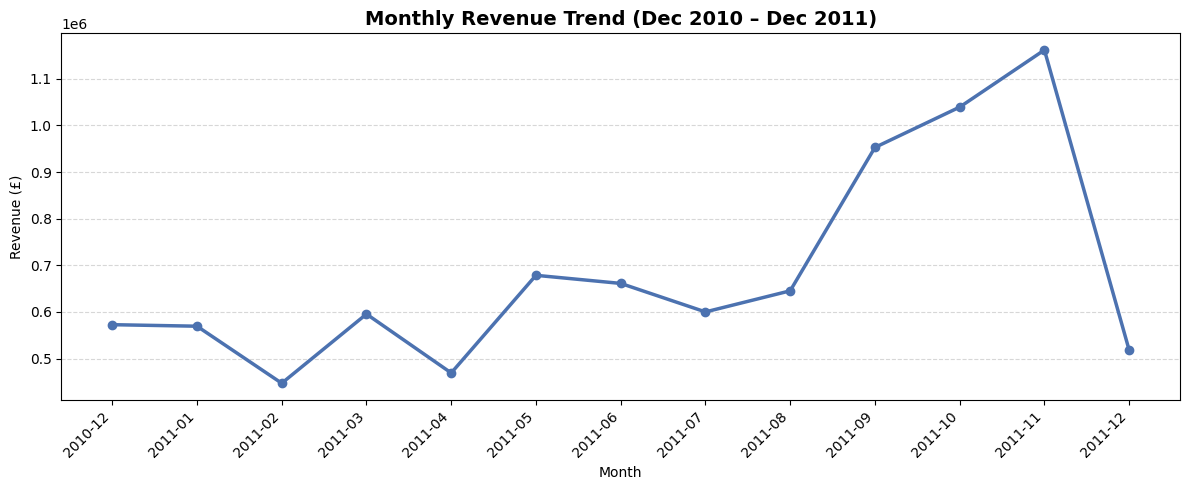

Saved!


In [31]:
plt.figure(figsize=(12, 5))
plt.plot(range(len(monthly_pd)), monthly_pd["Revenue"], marker="o", color="#4C72B0", linewidth=2.5)
plt.xticks(range(len(monthly_pd)), 
           [f"{int(r.Year)}-{int(r.Month):02d}" for _, r in monthly_pd.iterrows()], 
           rotation=45, ha="right")
plt.title("Monthly Revenue Trend (Dec 2010 – Dec 2011)", fontsize=14, fontweight="bold")
plt.ylabel("Revenue (£)")
plt.xlabel("Month")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("output/monthly_revenue.png", dpi=150)
plt.show()
print("Saved!")

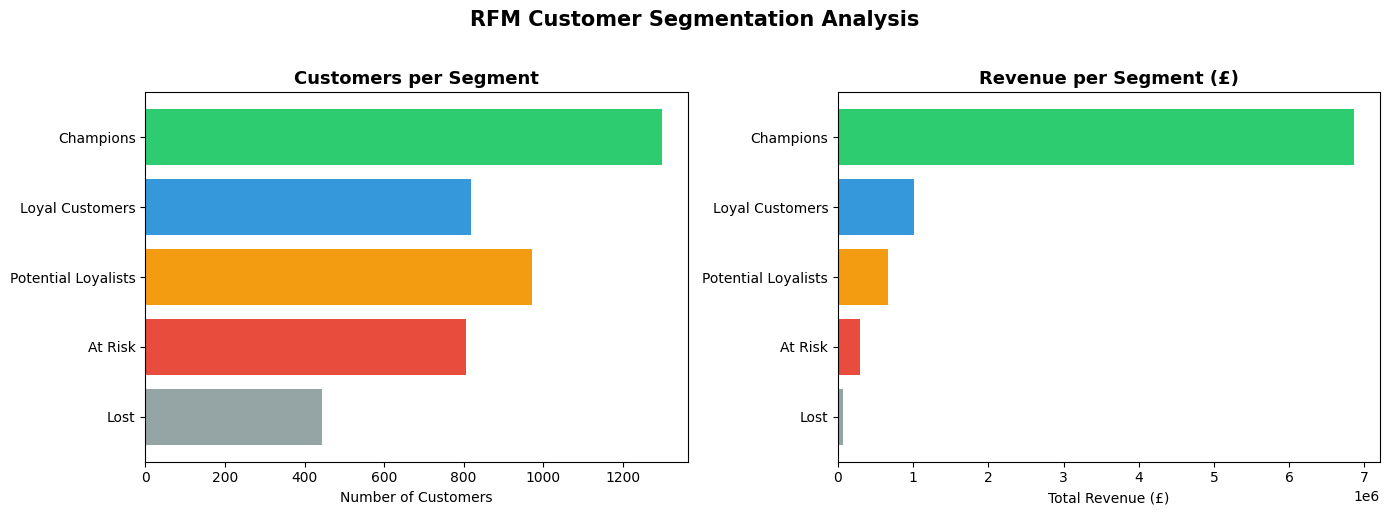

Saved!


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left — customer count per segment
colors = ["#2ecc71", "#3498db", "#f39c12", "#e74c3c", "#95a5a6"]
axes[0].barh(segment_pd["Segment"], segment_pd["Customers"], color=colors)
axes[0].set_title("Customers per Segment", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Number of Customers")
axes[0].invert_yaxis()

# right — revenue per segment
axes[1].barh(segment_pd["Segment"], segment_pd["Total_Revenue"], color=colors)
axes[1].set_title("Revenue per Segment (£)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Total Revenue (£)")
axes[1].invert_yaxis()

plt.suptitle("RFM Customer Segmentation Analysis", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("output/rfm_segments.png", dpi=150)
plt.show()
print("Saved!")

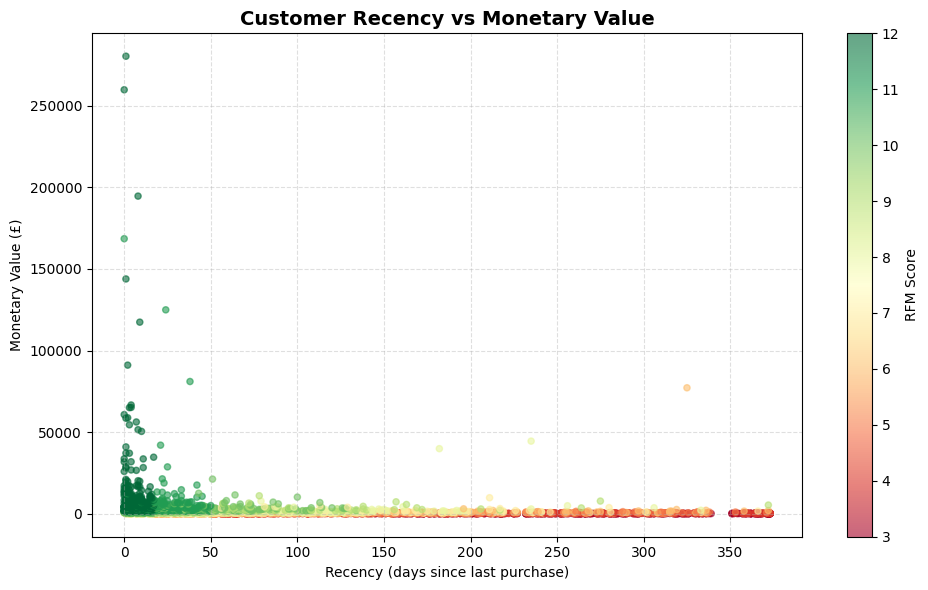

Saved!


In [33]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    rfm_pd["Recency"], 
    rfm_pd["Monetary"],
    c=rfm_pd["RFM_Score"], 
    cmap="RdYlGn", 
    alpha=0.6, 
    s=20
)
plt.colorbar(scatter, label="RFM Score")
plt.title("Customer Recency vs Monetary Value", fontsize=14, fontweight="bold")
plt.xlabel("Recency (days since last purchase)")
plt.ylabel("Monetary Value (£)")
plt.grid(linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("output/rfm_scatter.png", dpi=150)
plt.show()
print("Saved!")

**Spark SQL**

In [34]:
df_clean.createOrReplaceTempView("retail")
rfm_segmented.createOrReplaceTempView("rfm")

print("Views registered!")

Views registered!


**Basic GROUP BY (warm up)**

In [35]:
spark.sql("""
    SELECT
        Country,
        COUNT(DISTINCT InvoiceNo)   AS Orders,
        COUNT(DISTINCT CustomerID)  AS Customers,
        ROUND(SUM(TotalRevenue), 2) AS Revenue
    FROM retail
    WHERE Country != 'United Kingdom'
    GROUP BY Country
    ORDER BY Revenue DESC
    LIMIT 10
""").show()

+-----------+------+---------+---------+
|    Country|Orders|Customers|  Revenue|
+-----------+------+---------+---------+
|Netherlands|    94|        9|285446.34|
|       EIRE|   260|        3| 265545.9|
|    Germany|   457|       94|228867.14|
|     France|   389|       87|209024.05|
|  Australia|    57|        9|138521.31|
|      Spain|    90|       30| 61577.11|
|Switzerland|    51|       21| 56443.95|
|    Belgium|    98|       25| 41196.34|
|     Sweden|    36|        8| 38378.33|
|      Japan|    19|        8| 37416.37|
+-----------+------+---------+---------+



**HAVING clause (filter after aggregation)**

In [36]:
spark.sql("""
    SELECT
        CustomerID,
        COUNT(DISTINCT InvoiceNo) AS Orders,
        ROUND(SUM(TotalRevenue), 2) AS TotalSpent
    FROM retail
    GROUP BY CustomerID
    HAVING TotalSpent > 5000
    ORDER BY TotalSpent DESC
""").show(10)

+----------+------+----------+
|CustomerID|Orders|TotalSpent|
+----------+------+----------+
|     14646|    73| 280206.02|
|     18102|    60|  259657.3|
|     17450|    46| 194550.79|
|     16446|     2|  168472.5|
|     14911|   201| 143825.06|
|     12415|    21| 124914.53|
|     14156|    55| 117379.63|
|     17511|    31|  91062.38|
|     16029|    63|  81024.84|
|     12346|     1|   77183.6|
+----------+------+----------+
only showing top 10 rows


**Subquery (customers above average spend)**

In [37]:
spark.sql("""
    SELECT CustomerID, TotalSpent
    FROM (
        SELECT CustomerID, ROUND(SUM(TotalRevenue), 2) AS TotalSpent
        FROM retail
        GROUP BY CustomerID
    )
    WHERE TotalSpent > (SELECT AVG(TotalRevenue) * 10 FROM retail)
    ORDER BY TotalSpent DESC
    LIMIT 10
""").show()

+----------+----------+
|CustomerID|TotalSpent|
+----------+----------+
|     14646| 280206.02|
|     18102|  259657.3|
|     17450| 194550.79|
|     16446|  168472.5|
|     14911| 143825.06|
|     12415| 124914.53|
|     14156| 117379.63|
|     17511|  91062.38|
|     16029|  81024.84|
|     12346|   77183.6|
+----------+----------+



- Netherlands has only 9 customers but £285k revenue — highest value per customer outside UK
- Customer 14646 spent £280k across 73 orders — your top Champion
- Customer 12346 spent £77k in just 1 order — a massive one-time buyer, interesting outlier

**RANK customers by revenue within each country**

In [40]:
spark.sql("""
    SELECT Country, CustomerID, Revenue, CountryRank
    FROM (
        SELECT
            Country,
            CustomerID,
            ROUND(SUM(TotalRevenue), 2) AS Revenue,
            RANK() OVER (PARTITION BY Country ORDER BY SUM(TotalRevenue) DESC) AS CountryRank
        FROM retail
        GROUP BY Country, CustomerID
    )
    WHERE CountryRank = 1
    ORDER BY Revenue DESC
    LIMIT 10
""").show()

+--------------+----------+---------+-----------+
|       Country|CustomerID|  Revenue|CountryRank|
+--------------+----------+---------+-----------+
|   Netherlands|     14646|280206.02|          1|
|United Kingdom|     18102| 259657.3|          1|
|          EIRE|     14911|143825.06|          1|
|     Australia|     12415|124914.53|          1|
|        Sweden|     17404| 31906.82|          1|
|         Japan|     12753| 21429.39|          1|
|     Singapore|     12744| 21279.29|          1|
|       Germany|     12471| 19824.05|          1|
|        France|     12731| 18895.91|          1|
|         Spain|     12540| 13400.24|          1|
+--------------+----------+---------+-----------+



**Query 1 — Top customer per country**

- Netherlands' top customer (14646) alone spent £280k — more than Germany's entire top 10
- EIRE has only 3 customers total but their top one spent £143k — extremely concentrated

**Running total revenue per customer over time**

In [41]:
spark.sql("""
    SELECT
        CustomerID,
        InvoiceNo,
        InvoiceDate,
        ROUND(TotalRevenue, 2) AS OrderRevenue,
        ROUND(SUM(TotalRevenue) OVER (
            PARTITION BY CustomerID
            ORDER BY InvoiceDate
        ), 2) AS RunningTotal
    FROM retail
    WHERE CustomerID = 14646
    ORDER BY InvoiceDate
""").show(15)

+----------+---------+-------------------+------------+------------+
|CustomerID|InvoiceNo|        InvoiceDate|OrderRevenue|RunningTotal|
+----------+---------+-------------------+------------+------------+
|     14646|   539491|2010-12-20 10:09:00|        3.48|       70.96|
|     14646|   539491|2010-12-20 10:09:00|        3.48|       70.96|
|     14646|   539491|2010-12-20 10:09:00|         9.9|       70.96|
|     14646|   539491|2010-12-20 10:09:00|        1.95|       70.96|
|     14646|   539491|2010-12-20 10:09:00|         1.7|       70.96|
|     14646|   539491|2010-12-20 10:09:00|         2.1|       70.96|
|     14646|   539491|2010-12-20 10:09:00|         9.9|       70.96|
|     14646|   539491|2010-12-20 10:09:00|        4.25|       70.96|
|     14646|   539491|2010-12-20 10:09:00|         1.7|       70.96|
|     14646|   539491|2010-12-20 10:09:00|         2.5|       70.96|
|     14646|   539491|2010-12-20 10:09:00|         4.2|       70.96|
|     14646|   539491|2010-12-20 1

**Query 2 — Running total issue**
- The RunningTotal is grouping all rows of the same invoice together instead of accumulating row by row. This is because multiple items share the same timestamp.

**Month-over-month revenue growth**

In [43]:
spark.sql("""
    SELECT
        Year,
        Month,
        Revenue,
        LAG(Revenue) OVER (ORDER BY Year, Month) AS PrevMonthRevenue,
        ROUND((Revenue - LAG(Revenue) OVER (ORDER BY Year, Month)) 
              / LAG(Revenue) OVER (ORDER BY Year, Month) * 100, 1) AS GrowthPct
    FROM (
        SELECT Year, Month, ROUND(SUM(TotalRevenue), 2) AS Revenue
        FROM retail
        GROUP BY Year, Month
    )
    ORDER BY Year, Month
""").show()

+----+-----+----------+----------------+---------+
|Year|Month|   Revenue|PrevMonthRevenue|GrowthPct|
+----+-----+----------+----------------+---------+
|2010|   12| 572713.89|            NULL|     NULL|
|2011|    1| 569445.04|       572713.89|     -0.6|
|2011|    2| 447137.35|       569445.04|    -21.5|
|2011|    3| 595500.76|       447137.35|     33.2|
|2011|    4| 469200.36|       595500.76|    -21.2|
|2011|    5| 678594.56|       469200.36|     44.6|
|2011|    6| 661213.69|       678594.56|     -2.6|
|2011|    7| 600091.01|       661213.69|     -9.2|
|2011|    8|  645343.9|       600091.01|      7.5|
|2011|    9| 952838.38|        645343.9|     47.6|
|2011|   10|1039318.79|       952838.38|      9.1|
|2011|   11|1161817.38|      1039318.79|     11.8|
|2011|   12| 518192.79|      1161817.38|    -55.4|
+----+-----+----------+----------------+---------+



***Query 3 — Month-over-month growth ⭐ Most valuable***

- September 2011: +47.6% — the single biggest jump, holiday season kicks in
February 2011: -21.5% — post-Christmas slump
December 2011: -55.4% — dataset cuts off mid-month, not a real drop

**JOIN retail and rfm tables:**

In [47]:
spark.sql("""
    SELECT
        r.CustomerID,
        t.Country,
        r.Segment,
        r.Recency,
        r.Frequency,
        r.Monetary
    FROM rfm r
    JOIN (
        SELECT DISTINCT CustomerID, Country
        FROM retail
    ) t ON r.CustomerID = t.CustomerID
    WHERE r.Segment = 'Champions'
    ORDER BY r.Monetary DESC
    LIMIT 10
""").show()

+----------+--------------+---------+-------+---------+---------+
|CustomerID|       Country|  Segment|Recency|Frequency| Monetary|
+----------+--------------+---------+-------+---------+---------+
|     14646|   Netherlands|Champions|      1|       73|280206.02|
|     18102|United Kingdom|Champions|      0|       60| 259657.3|
|     17450|United Kingdom|Champions|      8|       46|194550.79|
|     16446|United Kingdom|Champions|      0|        2| 168472.5|
|     14911|          EIRE|Champions|      1|      201|143825.06|
|     12415|     Australia|Champions|     24|       21|124914.53|
|     14156|          EIRE|Champions|      9|       55|117379.63|
|     17511|United Kingdom|Champions|      2|       31| 91062.38|
|     16029|United Kingdom|Champions|     38|       63| 81024.84|
|     16684|United Kingdom|Champions|      4|       28| 66653.56|
+----------+--------------+---------+-------+---------+---------+



- Customer 16446 — spent £168k in just 2 orders. Massive bulk buyer.
- Customer 14911 — £143k across 201 orders. Most loyal customer in the dataset.
- Customer 12415 from Australia — £124k, 24 days since last purchase. High-value international Champion.